<a href="https://colab.research.google.com/github/solehas25h-salmasoleha/Soil-Kriging-Analysis/blob/main/kriging_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install geopandas geostatspy pykrige openpyxl contextily

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.1/78.1 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 13.2 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import geopandas as gpd
from shapely.geometry import Point

from sklearn.preprocessing import StandardScaler

from scipy.stats import pearsonr

from pykrige.ok import OrdinaryKriging

import warnings
warnings.filterwarnings("ignore")

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving soil.xlsx to soil.xlsx


In [ ]:
soil = pd.read_excel("soil.xlsx")

soil.head()

,x,y,lead,zinc
0,181072,333611,299,1022
1,181025,333558,277,1141
2,181165,333537,199,640
3,181298,333484,116,257
4,181307,333330,117,269


In [ ]:
soil['lead']
soil['lead'].describe()

,lead
count,155.000000
mean,153.361290
std,111.320054
min,37.000000
25%,72.500000
50%,123.000000
75%,207.000000
max,654.000000


Nugget : 10222.138718501597
Sill   : 10338.354277750903
Range  : 1.0


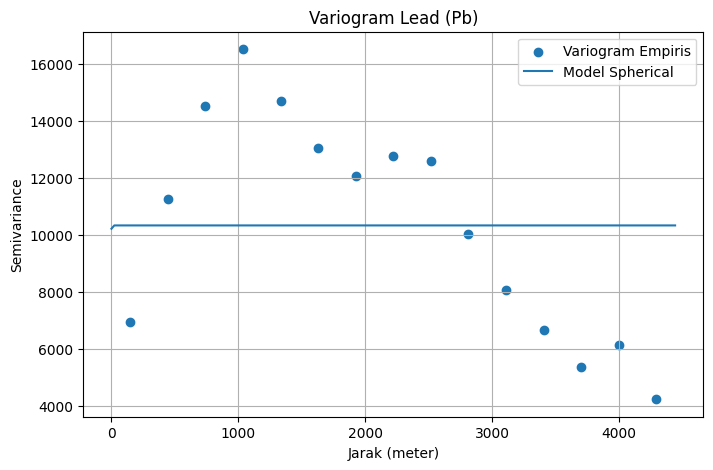

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


# koordinat
x = soil['x'].values
y = soil['y'].values
lead = soil['lead'].values


# menghitung jarak dan semivariansi
distance=[]
semivariance=[]

n=len(lead)

for i in range(n):
    dx=x[i+1:]-x[i]
    dy=y[i+1:]-y[i]

    h=np.sqrt(dx**2+dy**2)

    gamma=0.5*(lead[i+1:]-lead[i])**2

    distance.extend(h)
    semivariance.extend(gamma)


distance=np.array(distance)
semivariance=np.array(semivariance)


# membuat kelas jarak
bins=np.linspace(
    0,
    distance.max(),
    16
)


lag=[]
gamma=[]


for i in range(len(bins)-1):

    mask=(distance>=bins[i])&(distance<bins[i+1])

    lag.append(
        (bins[i]+bins[i+1])/2
    )

    gamma.append(
        semivariance[mask].mean()
    )


lag=np.array(lag)
gamma=np.array(gamma)


# model spherical

def spherical(h,nugget,sill,range_):

    return np.where(
        h<=range_,
        nugget+sill*(1.5*h/range_-0.5*(h/range_)**3),
        nugget+sill
    )


# fitting model

params,_=curve_fit(
    spherical,
    lag,
    gamma,
    bounds=(0,np.inf)
)


print("Nugget :",params[0])
print("Sill   :",params[0]+params[1])
print("Range  :",params[2])


# plot

plt.figure(figsize=(8,5))

plt.scatter(
    lag,
    gamma,
    label="Variogram Empiris"
)


h=np.linspace(
    0,
    distance.max(),
    200
)


plt.plot(
    h,
    spherical(h,*params),
    label="Model Spherical"
)


plt.xlabel("Jarak (meter)")
plt.ylabel("Semivariance")
plt.title("Variogram Lead (Pb)")
plt.legend()
plt.grid()

plt.show()

In [ ]:
def idw_interpolation(
    x,
    y,
    z,
    grid_x,
    grid_y,
    power=2
):

    grid_z = np.zeros(grid_x.shape)

    for i in range(grid_x.shape[0]):
        for j in range(grid_x.shape[1]):

            # menghitung jarak
            distance = np.sqrt(
                (x-grid_x[i,j])**2 +
                (y-grid_y[i,j])**2
            )

            # jika lokasi sama dengan titik sampel
            if np.any(distance==0):

                grid_z[i,j] = z[distance==0][0]

            else:

                weight = 1/(distance**power)

                grid_z[i,j] = (
                    np.sum(weight*z)
                    /
                    np.sum(weight)
                )

    return grid_z

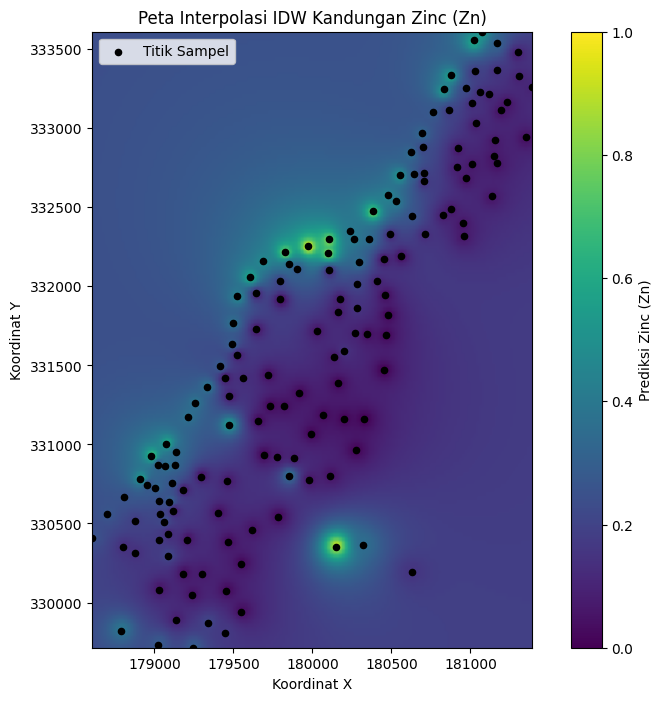

In [ ]:
x = soil['x'].values
y = soil['y'].values
zinc = soil['zinc'].values


grid_x_values = np.linspace(
    x.min(),
    x.max(),
    150
)


grid_y_values = np.linspace(
    y.min(),
    y.max(),
    150
)


grid_x, grid_y = np.meshgrid(
    grid_x_values,
    grid_y_values
)
zinc_idw = idw_interpolation(
    x,
    y,
    zinc,
    grid_x,
    grid_y,
    power=2
)
plt.figure(figsize=(10,8))


plt.imshow(
    zinc_idw,
    extent=[
        x.min(),
        x.max(),
        y.min(),
        y.max()
    ],
    origin='lower',
    cmap='viridis'
)


# titik sampel asli

plt.scatter(
    x,
    y,
    c='black',
    s=20,
    label="Titik Sampel"
)


plt.colorbar(
    label="Prediksi Zinc (Zn)"
)


plt.xlabel(
    "Koordinat X"
)

plt.ylabel(
    "Koordinat Y"
)


plt.title(
    "Peta Interpolasi IDW Kandungan Zinc (Zn)"
)


plt.legend()

plt.show()

<Figure size 800x500 with 0 Axes>

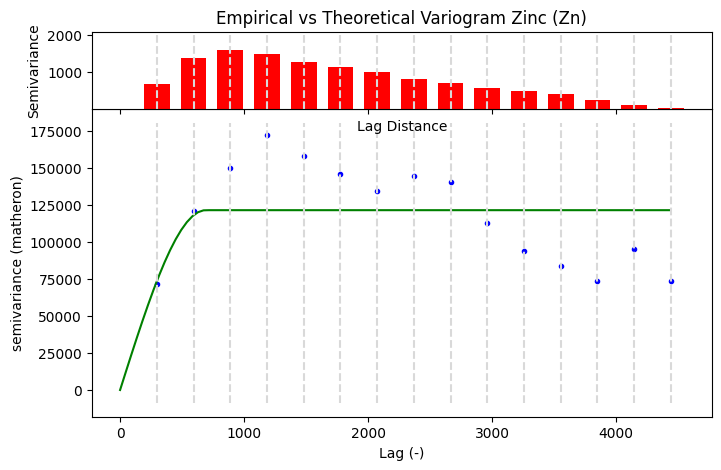

In [ ]:
!pip install scikit-gstat -q

import pandas as pd
import matplotlib.pyplot as plt
from skgstat import Variogram

# membaca data
soil = pd.read_excel("soil.xlsx")

# variogram Zinc
V = Variogram(
    soil[['x','y']].values,
    soil['zinc'].values,
    model='spherical',
    n_lags=15
)

# grafik empirical vs theoretical
plt.figure(figsize=(8,5))
V.plot()

plt.title("Empirical vs Theoretical Variogram Zinc (Zn)")
plt.xlabel("Lag Distance")
plt.ylabel("Semivariance")

plt.show()